<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exam/Exam_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling of Consumer Financial Behavior: An Analysis of Portuguese Bank Telemarketing Data

Group consisting of Ritu, Vikrant Singh and Kay Müller

Dataset: https://archive.ics.uci.edu/dataset/222/bank+marketing

Dataset Overview
Source: UCI Machine Learning Repository (Portuguese Banking Institution).

*   DOI: 10.24432/C5K306.
*   Size: 45,211 instances with 17 features
*   Type: Multivariate Classification.
*   Target Variable (y): Binary (Did the client subscribe to a term deposit? "yes" or "no").

In [55]:
import pandas as pd
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay

#Overview: Basis

**Important: Logic is linked to the order of execution. Please execute completely.**

In [56]:
# Load Kaggle dataset from my GitHub Repo
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/bank-full.csv', sep=';')
# df.head()
print("Shape", df.shape)
df.head()
print("\nData types")
print("="*40)
print(df.dtypes)

# Check Missing Values
missing_values = df.isnull().sum().sort_values(ascending=False)
if missing_values.sum() > 0: print(f"\n{'='*55}\nImportant: Edit missing values!\n{'='*55}")

Shape (45211, 17)

Data types
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


#5. Statistical Analysis

In [57]:
# Identify numerical columns
def define_numeric_cols():
  numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
  print(f"Numerical columns: {numeric_cols}")
  return numeric_cols

numeric_cols = define_numeric_cols()

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


##5.1 Essential descriptive statistics (Overview)

In [58]:
# Advanced statistics: mean, variance, skewness
stats_df = pd.DataFrame({
  'Mean': df[numeric_cols].mean(),
  'Median': df[numeric_cols].median(),
  'Variance': df[numeric_cols].var(),
  'Standard deviation': df[numeric_cols].std(),
  'Skewness': df[numeric_cols].skew(),
  'Min': df[numeric_cols].min(),
  'Max': df[numeric_cols].max()
}).round(3)

print("\nDetailed statistics for numerical features")
print("="*80)
stats_df


Detailed statistics for numerical features


,Mean,Median,Variance,Standard deviation,Skewness,Min,Max
age,40.936,39.0,112.758,10.619,0.685,18,95
balance,1362.272,448.0,9270598.954,3044.766,8.360,-8019,102127
day,15.806,16.0,69.264,8.322,0.093,1,31
duration,258.163,180.0,66320.574,257.528,3.144,0,4918
campaign,2.764,2.0,9.598,3.098,4.899,1,63
pdays,40.198,-1.0,10025.766,100.129,2.616,-1,871
previous,0.580,0.0,5.306,2.303,41.846,0,275


####Explanation of critical features in advance

The "**balance**" feature is subject to high variance due to heterogeneous customers (rich and poor). The median provides more information here than the mean. This value is inherently subject to outliers and dynamic distribution, which is important for preprocessing.

The "**duration**" feature is subject to high variance. This allows for deductions such as rejections/failures between 10 and 30 seconds, normal (promising) conversations between 2 and 5 minutes, customers with high interest between 10 and 20 minutes, etc. However, this variance also leads to enormous outliers and distortions in the weighting.

The "**pdays**" feature is a special case that provides central and Boolean information about the contact situation. This also explains the high variance between customers who have already been contacted and a high number of customers who have not been contacted in terms of time, which can be seen in the median and mean comparison, among other things.





###5.1.1 Interpretation of skewness

In [59]:
results = []
def skew_num_features():

  print("\nInterpretation of skewness")
  print("="*55)
  for col in numeric_cols:
    skew = df[col].skew()
    if skew > 1:
      interpretation = "strongly skewed to the right"
    elif skew > 0.5:
      interpretation = "moderately right-leaning"
    elif skew > -0.5:
      interpretation = "approximately symmetrical"
    elif skew > -1:
      interpretation = "moderately left-leaning"
    else:
      interpretation = "strongly left-leaning"
    results.append({
    "Feature": col,
    "Skew": interpretation,
    })
    print(f"{col}: Schiefe = {skew:.3f} ({interpretation})")

skew_num_features()
print("\n")
results_df = pd.DataFrame(results).set_index("Feature")
results_df.style.highlight_max(axis=0, color="peachpuff")


Interpretation of skewness
age: Schiefe = 0.685 (moderately right-leaning)
balance: Schiefe = 8.360 (strongly skewed to the right)
day: Schiefe = 0.093 (approximately symmetrical)
duration: Schiefe = 3.144 (strongly skewed to the right)
campaign: Schiefe = 4.899 (strongly skewed to the right)
pdays: Schiefe = 2.616 (strongly skewed to the right)
previous: Schiefe = 41.846 (strongly skewed to the right)




,Skew
Feature,
age,moderately right-leaning
balance,strongly skewed to the right
day,approximately symmetrical
duration,strongly skewed to the right
campaign,strongly skewed to the right
pdays,strongly skewed to the right
previous,strongly skewed to the right


####Skewed significance and interpretation

| Feature | Skew | Significance and relevance |
|---|---|---|
| **age** | Moderately right-skewed | Many customers are middle-aged and few  are over 90 years old. Corresponds to a natural variable <br>that runs continuously. |
| **balance** | Strong right-skewed | Extreme outliers can negatively influence the model and distort reality, e.g. if a customer with 100 EUR <br>is a hundred times more valuable than a customer with 10,000 EUR. However, it can serve as important <br>information, e.g. for premium customers with high account balances who are also eligible for other <br>offers from the bank, such as shares, funds, savings schemes and insurance policies. |
| **day** | Approximately right-skewed | This value is not really relevant, as it represents the day of the month and thus also the day of the week. <br>This would be useful if the most successful days were observed, e.g. after an interest rate adjustment by <br>the central bank. |
| **duration** | Strong right-skewed | There is a problem with the relationship here. A conversation lasting 3,600 seconds is not necessarily <br>better than a conversation lasting 900 seconds if the average success rate is 900 seconds. |
| **campaign** | Strong right-skewed | As with duration, the problem here is also the relationship. Ten contact attempts are not necessarily <br>better than three or four, where success may still be possible. |
| **pdays** | Strong right-skewed | This is an indicator that an enormous number of customers have not yet been contacted (-1). This is<br> important for further evaluations, as only a small proportion represents a "real" distribution. <br>*POSSIBLE REMEDY: Split feature in advance.*|
| **previous** | Strong right-skewed | As very few customers from the dataset have been contacted, this also reflects the distribution of pdays. |



---
For the feature "**education**" with natural order ('basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown'), the skew representation makes perfect sense, but requires encoding, which is performed as follows.


In [60]:
# Label-Encoding
print("\nEducation Label-Encoding")
print("="*55)

# Define order (from low to high)
education_order = {
  'unknown': 0,    # No information
  'primary': 1,    # primary school
  'secondary': 2,  # secondary school
  'tertiary': 3    # College/University
}

# Apply coding (ordered)
df['ml_education'] = df['education'].map(education_order)

print("\nLabel-Encoding Schema:")
for label, code in education_order.items():
  count = (df['education'] == label).sum()
  percent = count / len(df) * 100
  print(f"  {code} = {label:12s} | n = {count:6d} ({percent:5.2f}%)")

numeric_cols = define_numeric_cols()
skew_num_features()


Education Label-Encoding

Label-Encoding Schema:
  0 = unknown      | n =   1857 ( 4.11%)
  1 = primary      | n =   6851 (15.15%)
  2 = secondary    | n =  23202 (51.32%)
  3 = tertiary     | n =  13301 (29.42%)
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'ml_education']

Interpretation of skewness
age: Schiefe = 0.685 (moderately right-leaning)
balance: Schiefe = 8.360 (strongly skewed to the right)
day: Schiefe = 0.093 (approximately symmetrical)
duration: Schiefe = 3.144 (strongly skewed to the right)
campaign: Schiefe = 4.899 (strongly skewed to the right)
pdays: Schiefe = 2.616 (strongly skewed to the right)
previous: Schiefe = 41.846 (strongly skewed to the right)
ml_education: Schiefe = -0.627 (moderately left-leaning)


Explanation:

The majority of bank customers are well educated (secondary school or higher). The following correlation is interesting in this regard.

###5.1.2 Interpretation of correlation

In [61]:
correlation_matrix = df[numeric_cols].corr()

print("\nCorrelation Matrix")
print("="*80)
correlation_matrix.round(3)


Correlation Matrix


,age,balance,day,duration,campaign,pdays,previous,ml_education
age,1.000,0.098,-0.009,-0.005,0.005,-0.024,0.001,-0.174
balance,0.098,1.000,0.005,0.022,-0.015,0.003,0.017,0.051
day,-0.009,0.005,1.000,-0.030,0.162,-0.093,-0.052,0.022
duration,-0.005,0.022,-0.030,1.000,-0.085,-0.002,0.001,0.003
campaign,0.005,-0.015,0.162,-0.085,1.000,-0.089,-0.033,0.000
pdays,-0.024,0.003,-0.093,-0.002,-0.089,1.000,0.455,0.007
previous,0.001,0.017,-0.052,0.001,-0.033,0.455,1.000,0.025
ml_education,-0.174,0.051,0.022,0.003,0.000,0.007,0.025,1.000


Explanation:

The strongest correlation is between pdays and previous, at 0.455. This is evident in the fact that customers who have been contacted previously also have more previous contacts. There is an overlap between the features. However, the interpretation is timing vs. frequency of contact.

###5.1.3 Die Zielvariable (subscribed a term deposit?)

In [62]:
print("\nDistribution of the target variable 'y'")
print("="*55)
y_counts = df['y'].value_counts()
y_pct = df['y'].value_counts(normalize=True) * 100

print(f"\nNumber:")
print(y_counts)
print(f"\nPercentage:")
print(y_pct.round(2))
print(f"\nNote: The dataset is unbalanced: {y_pct['no']:.1f}% 'no' vs {y_pct['yes']:.1f}% 'yes'")


Distribution of the target variable 'y'

Number:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64

Note: The dataset is unbalanced: 88.3% 'no' vs 11.7% 'yes'


##5.2 Statistical plots

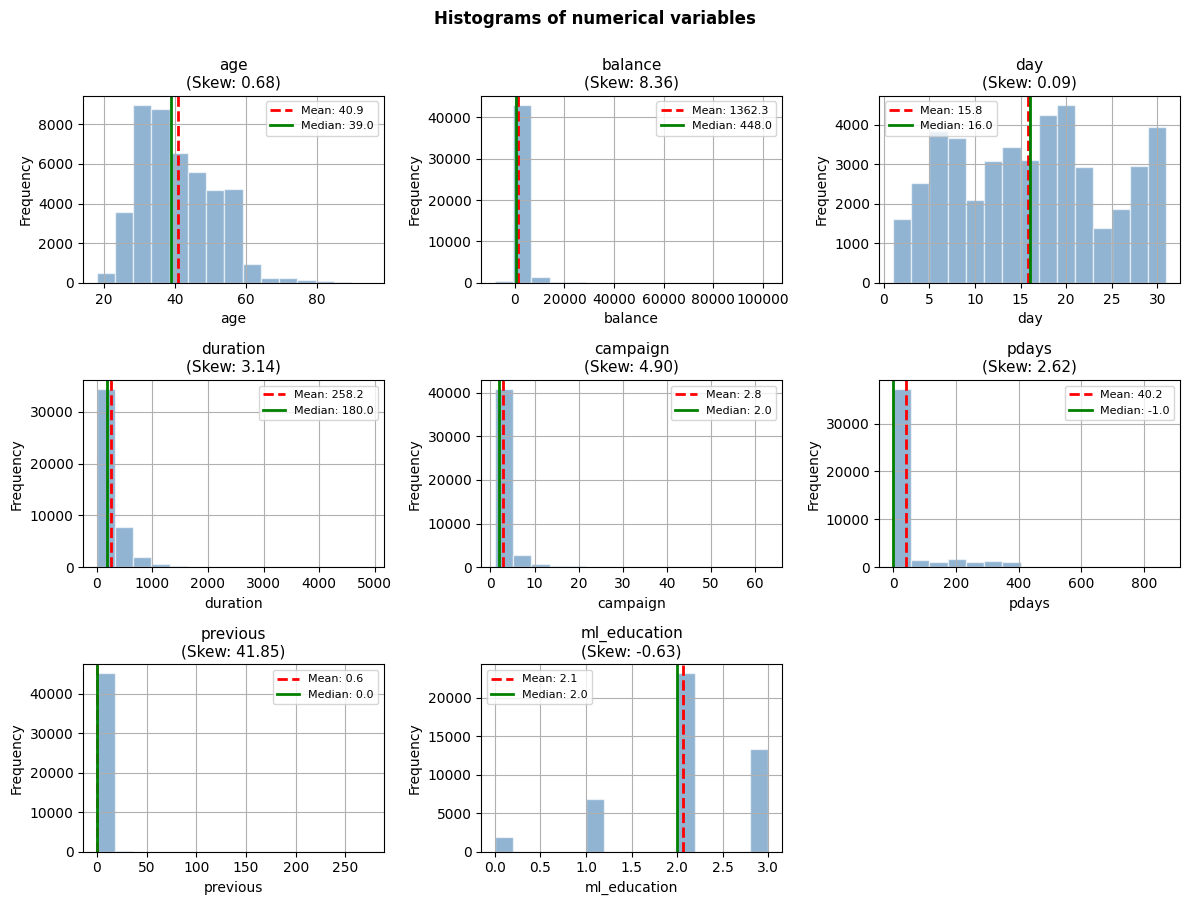

In [63]:
# Histograms for all numerical variables
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  ax = axes[i]

  df[col].hist(bins=15, ax=ax, color='steelblue', edgecolor='white', alpha=0.6)

  # Plot the mean and median
  ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
  ax.axvline(df[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df[col].median():.1f}')

  ax.set_title(f'{col}\n(Skew: {df[col].skew():.2f})', fontsize=11)
  ax.set_xlabel(col)
  ax.set_ylabel('Frequency')
  ax.legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
  fig.delaxes(axes[j])

plt.suptitle('Histograms of numerical variables', fontweight='bold', y=1)
plt.tight_layout()
plt.show()

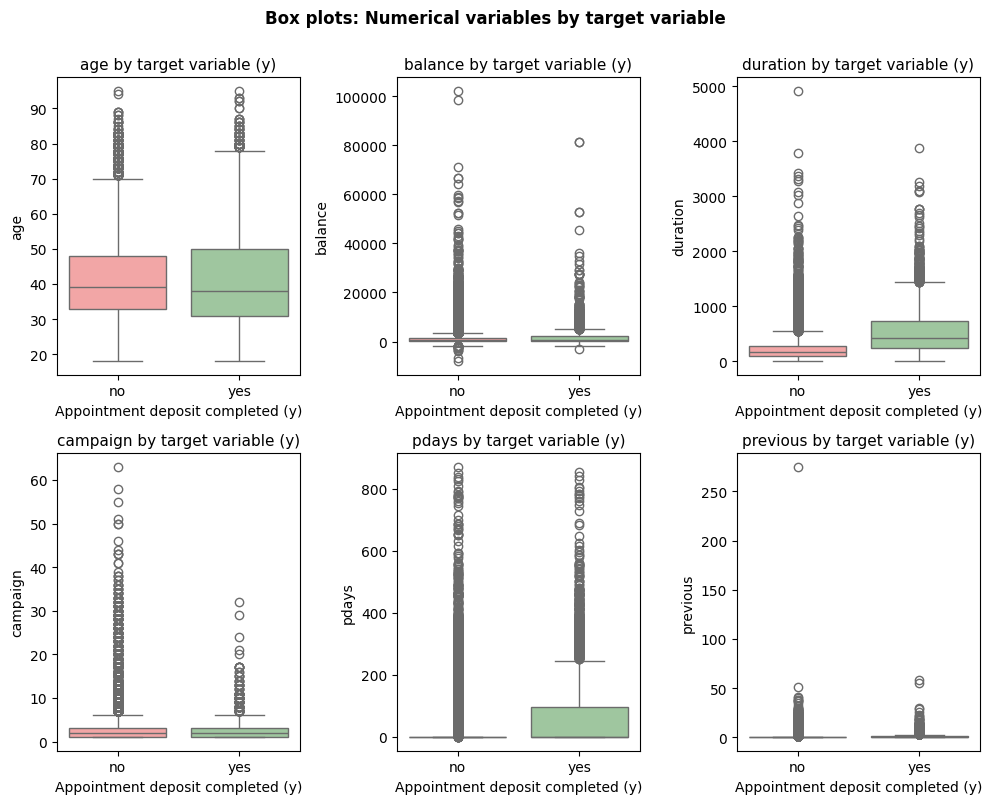


Box plots show the distribution and outliers per group.


In [64]:
# Box plots for selected variables by target variable
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

selected_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

for i, col in enumerate(selected_cols):
  ax = axes[i]
  sns.boxplot(data=df, x='y', y=col, ax=ax,
    hue='y',
    palette=['#ff9999', '#99cc99'],
    legend=False)
  ax.set_title(f'{col} by target variable (y)', fontsize=11)
  ax.set_xlabel('Appointment deposit completed (y)')
  ax.set_ylabel(col)

plt.suptitle('Box plots: Numerical variables by target variable', fontweight='bold', y=1)
plt.tight_layout()
plt.show()

print("\nBox plots show the distribution and outliers per group.")

Explanation:

Tree models split according to threshold values, which is why outliers do not particularly influence these models. Removing the outliers would also lead to a loss of information, as the minority classification ("Yes" cases) would also be affected. The StandardScaler is relevant for KNN.

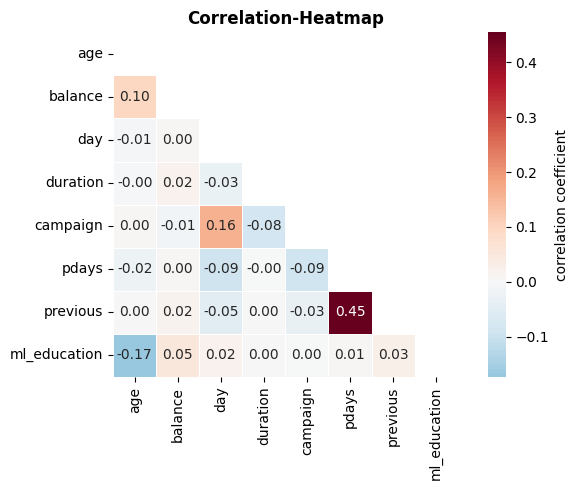


Red: Positive correlation | Blue: Negative correlation
Strong correlation between 'pdays' and 'previous' (previous campaign data)


In [65]:
# Correlation heat map
plt.figure(figsize=(7, 5))

# Unmirrored display for quicker understanding
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix,
  annot=True,
  fmt='.2f',
  cmap='RdBu_r',
  center=0,
  mask=mask,
  square=True,
  linewidths=0.5,
  cbar_kws={'label': 'correlation coefficient'})

plt.title('Correlation-Heatmap', fontweight='bold', y=1)
plt.tight_layout()
plt.show()

print("\nRed: Positive correlation | Blue: Negative correlation")
print("Strong correlation between 'pdays' and 'previous' (previous campaign data)")

Explanation:

The matrix shows that the features are almost independent of each other, with the exception of the correlation between previous and pdays.

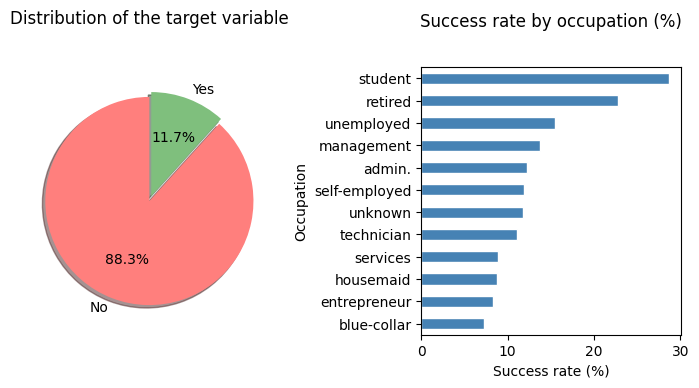


Students and pensioners have the highest success rate.


In [66]:
# Distribution of the target variable as a pie chart
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Pie chart
colors = ['#ff7f7d', '#7fbf7d']
explode = (0, 0.05)
axes[0].pie(df['y'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%',
  colors=colors, explode=explode, startangle=90, shadow=True)
axes[0].set_title('Distribution of the target variable', y=1.15)

# Bar chart by occupation
job_yes = df[df['y'] == 'yes']['job'].value_counts()
job_no = df[df['y'] == 'no']['job'].value_counts()
job_rate = (job_yes / (job_yes + job_no) * 100).sort_values(ascending=True)

job_rate.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Success rate by occupation (%)', y=1.12)
axes[1].set_xlabel('Success rate (%)')
axes[1].set_ylabel('Occupation')

plt.tight_layout()
plt.show()

print("\nStudents and pensioners have the highest success rate.")

####Final remarks on statistical analysis
Why noise injection was not performed:
The evaluations showed that overfitting is not a problem, but rather the imbalance and the signal in relation.

Why linear models are not used:
Logistic regression refers to linear boundaries, which are rarely found in the dataset. Non-linear relationships dominate the dataset, such as age, balance and previous contact. These relationships are captured by tree models.


# 6. Supervised Learning

In [67]:
# Copy of the DataFrame for ML
df_ml = df.copy()

##6.1 Special transformation measures

In [68]:
# Identify categorical columns
categorical_cols = df_ml.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')  # Treat target variable separately
print(f"Kategorische Spalten: {categorical_cols}")

Kategorische Spalten: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [69]:
# Encoding individually (binary)
df_ml['ml_default'] = (df_ml['default'] == 'yes').astype(int)
df_ml['ml_housing'] = (df_ml['housing'] == 'yes').astype(int)
df_ml['ml_loan'] = (df_ml['loan'] == 'yes').astype(int)

# Remove original columns (already encoded for skewness)
df_ml = df_ml.drop(['education', 'default', 'housing', 'loan'], axis=1)

# OneHot-Encoding
df_ml = pd.get_dummies(df_ml,
	columns=['job', 'marital', 'contact', 'month', 'poutcome'],
	drop_first=False)

# Problem Duration
df_ml = df_ml.drop(['duration'], axis=1)
#df_ml['duration'] = np.log1p(df_ml['duration'])

# Encode target variable
df_ml['y'] = (df_ml['y'] == 'yes').astype(int)

# Split pdays
df_ml['ml_pdays_contacted'] = (df_ml['pdays'] > 0).astype(int) # True wenn > 0
df_ml['ml_pdays_since_contact'] = df_ml['pdays'].apply(lambda x: max(0, x)) # -1 to >= 0
df_ml = df_ml.drop('pdays', axis=1)

print("Encoded data:")
df_ml.head(3)

# Output in CSV format for separate viewing/checking
#df_ml.to_csv('temp_ausgabe.csv', index=False)

Encoded data:


,age,balance,day,campaign,previous,y,ml_education,ml_default,ml_housing,ml_loan,...,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,ml_pdays_contacted,ml_pdays_since_contact
0,58,2143,5,1,0,0,3,0,1,0,...,True,False,False,False,False,False,False,True,0,0
1,44,29,5,1,0,0,2,0,1,0,...,True,False,False,False,False,False,False,True,0,0
2,33,2,5,1,0,0,2,0,1,1,...,True,False,False,False,False,False,False,True,0,0


#### Transformation measures in detail: feature engineering and encoding
The following differentiated measures were necessary to prepare for supervised learning:
| Feature | Measure | Target |
|---|---|---|
| **education** | Label encoding | Labels: 0 = unknown (no information), 1 = primary (primary school),  2 = secondary <br>(secondary school), 3 = tertiary (college/university) |
| **job** | OneHot encoding | Breakdown into several columns (true/false) |
| **marital** | OneHot encoding | Breakdown into 3 columns (true/false) |
| **contact** | OneHot encoding | Breakdown into 3 columns (true/false) |
| **month** | OneHot encoding | Breakdown into 12 columns (True/False) |
| **poutcome** | OneHot encoding | Breakdown into 4 columns (True/False) |
| **poutcome** | OneHot encoding | Breakdown into 4 columns (True/False) |
| **default** | Binary | Breakdown into True/False |
| **housing** | Binary | Breakdown into True/False |
| **loan** | Binary | Breakdown into True/False |
| **y** | Binary | Breakdown of target variable into True/False |
---
#### Special cases

The "**duration**" feature poses a problem because it is very dominant. Log transformation brought little improvement here. Elimination is the better choice here to ensure the authenticity of the models. In addition, the duration is only known after contact (not at the time of prediction). The contact duration correlates with "yes" as the outcome, but this is merely a result.

The "**pdays**" feature acts as a binary model (contacted: yes/no) which can represent three cases (only contacted customers; only non-contacted customers; all customers). Splitting the binary bond into two customer groups.

In [70]:
# Separate features and target variable
X = df_ml.drop('y', axis=1)
y = df_ml['y']

print(f"\nTarget distribution:\n{y.value_counts()}")


Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


In [71]:
# Train-Test-Split (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]} Samples (80%)")
print(f"Test Set: {X_test.shape[0]} Samples (20%)")

Training Set: 36168 Samples (80%)
Test Set: 9043 Samples (20%)


In [72]:
# Feature scaling for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling performed required for KNN")

Feature scaling performed required for KNN


Note: **Scaling** necessary for KNN. Hardly relevant for tree models, as thresholds are defined.

##6.2 Models and their evaluation

In [73]:
# Model evaluation function
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
  if hasattr(model, 'predict_proba'):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
  else:
    y_pred = model.predict(X_test)
    y_pred_proba = None

  # Calculate metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  # Correlation Coefficient
  from sklearn.metrics import matthews_corrcoef
  mcc = matthews_corrcoef(y_test, y_pred)

  # ROC-AUC
  roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

  return {
    'Model': model_name,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'y_pred': y_pred,
    'y_pred_proba': y_pred_proba
  }

In [74]:
# Train decision tree
dt_model = DecisionTreeClassifier(
  max_depth=10,
  min_samples_split=20,
  min_samples_leaf=10,
  class_weight='balanced',
  random_state=42
)

dt_model.fit(X_train, y_train)
dt_results = evaluate_model(dt_model, X_test, y_test, 'Decision Tree', threshold=0.8)

print("Decision Tree")
print("="*25)
print(f"Accuracy:  {dt_results['Accuracy']:.4f}")
print(f"Precision: {dt_results['Precision']:.4f}")
print(f"Recall:    {dt_results['Recall']:.4f}")
print(f"F1-Score:  {dt_results['F1-Score']:.4f}")
print(f"ROC-AUC:   {dt_results['ROC-AUC']:.4f}")

Decision Tree
Accuracy:  0.8828
Precision: 0.4989
Recall:    0.4282
F1-Score:  0.4608
ROC-AUC:   0.7614


In [75]:
# KNN training
knn_model = KNeighborsClassifier(
  # k = 5 better compromise than 12/11 in terms of better recall and lower precision
  # And accuracy is clouded by imbalance in the classes
  n_neighbors=5,
  weights='distance',
  metric='minkowski',
  p=2
)

knn_model.fit(X_train_scaled, y_train)
knn_results = evaluate_model(knn_model, X_test_scaled, y_test, 'KNN')

k_range = range(1, 15)
knn_scores = {"k": [], "Accuracy": [], "F1-Score": []}

for k in k_range:
	knn = KNeighborsClassifier(n_neighbors=k)
	knn.fit(X_train_scaled, y_train)
	y_pred_k = knn.predict(X_test_scaled)

	knn_scores["k"].append(k)
	knn_scores["Accuracy"].append(accuracy_score(y_test, y_pred_k))
	knn_scores["F1-Score"].append(f1_score(y_test, y_pred_k))

knn_df = pd.DataFrame(knn_scores)
print(knn_df.to_string(index=False))

# Besten k-Wert finden
best_k = knn_df.loc[knn_df['Accuracy'].idxmax()]
print(f"\nBest k-value: {int(best_k['k'])} with accuracy: {best_k['Accuracy']:.4f}")

print("\nK-Nearest Neighbors (KNN)")
print("="*25)
print(f"Accuracy:  {knn_results['Accuracy']:.4f}")
print(f"Precision: {knn_results['Precision']:.4f}")
print(f"Recall:    {knn_results['Recall']:.4f}")
print(f"F1-Score:  {knn_results['F1-Score']:.4f}")
print(f"ROC-AUC:   {knn_results['ROC-AUC']:.4f}")

 k  Accuracy  F1-Score
 1  0.839544  0.297337
 2  0.884109  0.219076
 3  0.880902  0.338045
 4  0.888643  0.263350
 5  0.887537  0.334859
 6  0.890302  0.279070
 7  0.890855  0.332657
 8  0.889749  0.271731
 9  0.891187  0.324176
10  0.892182  0.295011
11  0.893398  0.340629
12  0.893730  0.305134
13  0.892514  0.334247
14  0.893730  0.318923

Best k-value: 12 with accuracy: 0.8937

K-Nearest Neighbors (KNN)
Accuracy:  0.8834
Precision: 0.5039
Recall:    0.2467
F1-Score:  0.3312
ROC-AUC:   0.7083


In [76]:
# Train Random Forest
rf_model = RandomForestClassifier(
  n_estimators=100,
  max_depth=15,
  min_samples_split=10,
  min_samples_leaf=5,
  class_weight='balanced',
  random_state=42,
  n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest', threshold=0.65)

print("Random Forest")
print("="*25)
print(f"Accuracy:  {rf_results['Accuracy']:.4f}")
print(f"Precision: {rf_results['Precision']:.4f}")
print(f"Recall:    {rf_results['Recall']:.4f}")
print(f"F1-Score:  {rf_results['F1-Score']:.4f}")
print(f"ROC-AUC:   {rf_results['ROC-AUC']:.4f}")

Random Forest
Accuracy:  0.8870
Precision: 0.5224
Recall:    0.3960
F1-Score:  0.4505
ROC-AUC:   0.8023


##6.3 Comparison of models

In [77]:
results = []
for r in [dt_results, knn_results, rf_results]:
  results.append({
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1-Score': r['F1-Score'],
    'ROC-AUC': r['ROC-AUC']
  })

results_df = pd.DataFrame(results)
print("=" * 80)
print("Model comparison (metrics)")
print("=" * 80)
results_df.round(4)

results_df_output = results_df
results_df_output = pd.DataFrame(results).set_index("Model")
results_df_output.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen")

Model comparison (metrics)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Decision Tree,0.8828,0.4989,0.4282,0.4608,0.7614
KNN,0.8834,0.5039,0.2467,0.3312,0.7083
Random Forest,0.8870,0.5224,0.3960,0.4505,0.8023


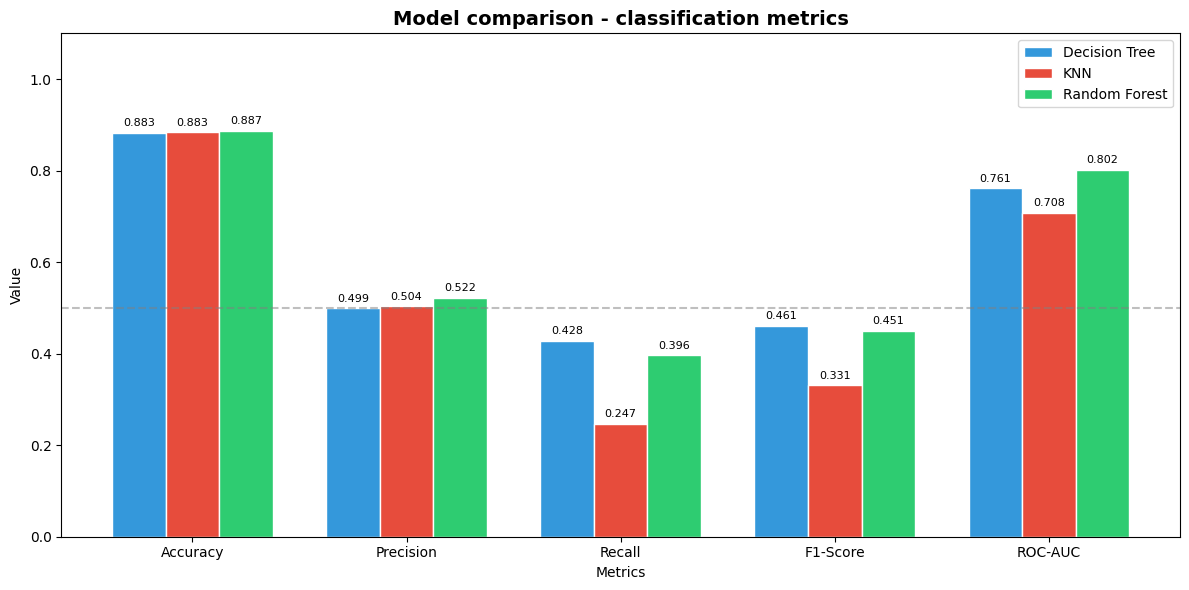

In [78]:
# Visual comparison of the models
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

colors = ['#3498db', '#e74c3c', '#2ecc71']
models = ['Decision Tree', 'KNN', 'Random Forest']

for i, (model, color) in enumerate(zip(models, colors)):
  values = results_df[results_df['Model'] == model][metrics].values[0]
  bars = ax.bar(x + i * width, values, width, label=model, color=color, edgecolor='white')

  # Werte über Balken
  for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
      f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Value')
ax.set_title('Model comparison - classification metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

####Interpretation

The consistently high **accuracy** is due to the high number of "No" values. A simple prediction of "No" weighting without reference would therefore have a similar effect.

**Recall** highlights the core problem of all models. The majority of all customers with closing potential are overlooked.

**ROC-AUC** shows the comparatively good performance of the Random Forest model, which correctly assigns the maximum score probability to closing customers ("Yes"). Threshold is crucial here, but the influence on precision must be taken into account.

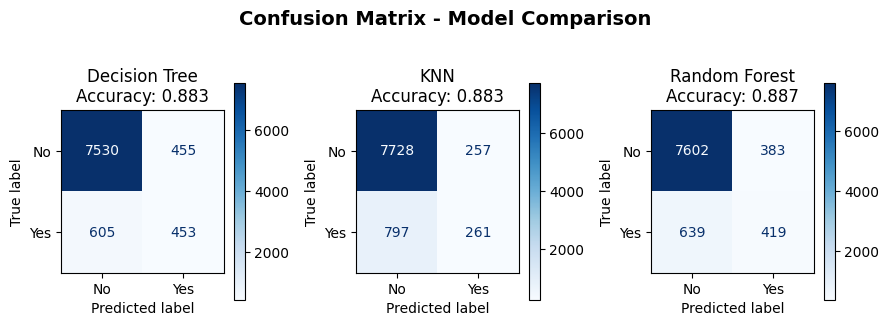


Interpretation der Confusion Matrix
True Negative (TN): Correctly predicted as 'No' (top left)
False positive (FP): Incorrectly predicted as 'Yes' (top right)
False Negative (FN): Incorrectly predicted as 'No' (bottom left)
True positive (TP): Correctly predicted as 'Yes' (bottom right)


In [79]:
# Confusion matrix for all three models
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

models_data = [
  (dt_results, 'Decision Tree'),
  (knn_results, 'KNN'),
  (rf_results, 'Random Forest')
]

for ax, (results, name) in zip(axes, models_data):
  cm = confusion_matrix(y_test, results['y_pred'])
  disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
  disp.plot(ax=ax, cmap='Blues', values_format='d')
  ax.set_title(f'{name}\nAccuracy: {results["Accuracy"]:.3f}', fontsize=12)

plt.suptitle('Confusion Matrix - Model Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nInterpretation der Confusion Matrix")
print("="*75)
print("True Negative (TN): Correctly predicted as 'No' (top left)")
print("False positive (FP): Incorrectly predicted as 'Yes' (top right)")
print("False Negative (FN): Incorrectly predicted as 'No' (bottom left)")
print("True positive (TP): Correctly predicted as 'Yes' (bottom right)")

####Interpretation

**KNN** is clearly the weakest, with only 261 correctly recognised "Yes" cases out of 1058.

**Decision Tree** performs better, with 453 correctly recognised "Yes" cases out of 1058.

**Random Forest** performs best here with 419 correctly recognised "Yes" cases out of 1058, but 383 false positives perform best here.

In summary, all models miss over 50% of customers who are actually willing to complete a transaction.

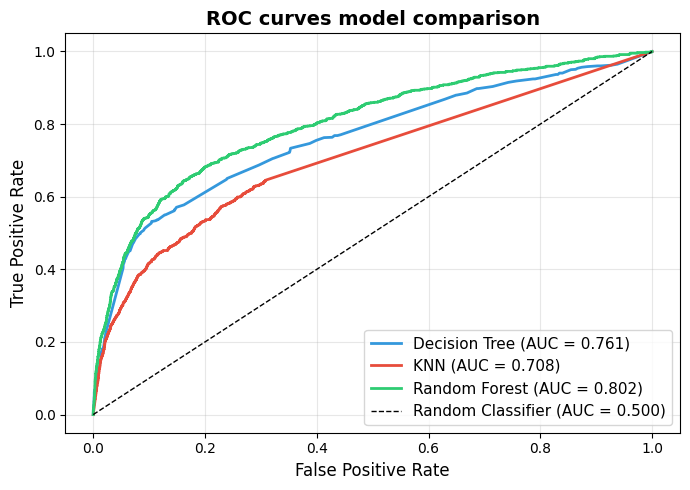


Interpretation of the ROC curve
The further the curve extends into the upper left corner, the better.
AUC = 1.0: Perfect Classification
AUC = 0.5: No better than chance (dashed line)
AUC > 0.8: Considered good classification performance


In [80]:
# ROC curves
plt.figure(figsize=(7, 5))

colors = ['#3498dc', '#e74c3b', '#2ecc72']

for (results, name), color in zip(models_data, colors):
  if results['y_pred_proba'] is not None:
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    auc = roc_auc_score(y_test, results['y_pred_proba'])
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Diagonale (Random Classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC curves model comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation of the ROC curve")
print("="*75)
print("The further the curve extends into the upper left corner, the better.")
print("AUC = 1.0: Perfect Classification")
print("AUC = 0.5: No better than chance (dashed line)")
print("AUC > 0.8: Considered good classification performance")

Interpretation

Random Forest clearly performs best. It is furthest away from the random line. It can detect positive cases and, in relative terms, produces the fewest false alarms.

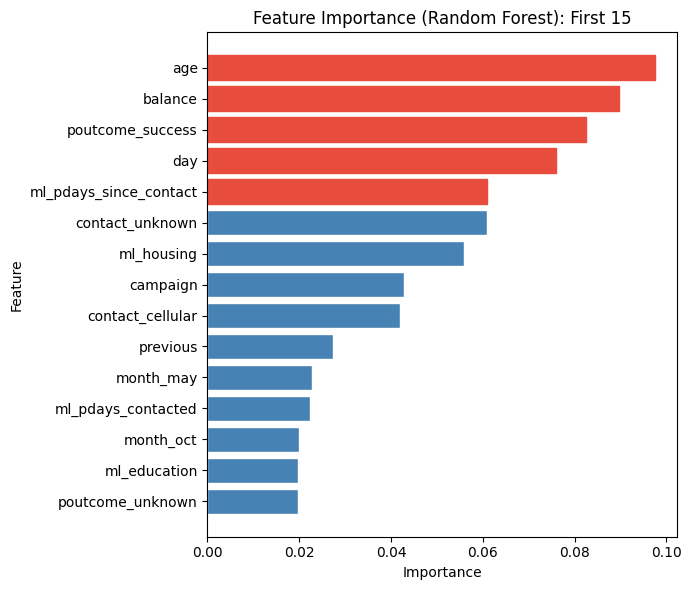

In [81]:
# Feature Importance aus Random Forest
feature_importance = pd.DataFrame({
  'Feature': X.columns,
  'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(7, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
  color='steelblue', edgecolor='white')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest): First 15')

# Top 5 Features hervorheben
top5 = feature_importance.tail(5)['Feature'].tolist()
for i, (idx, row) in enumerate(feature_importance.iterrows()):
  if row['Feature'] in top5:
    plt.gca().get_children()[feature_importance.index.tolist().index(idx)].set_color('#e74c3c')

plt.tight_layout()
plt.show()


#6.4 Conclusion
Without the "duration" feature, there is little signal from the remaining features. This means that many customers have similar parameters and the conclusion appears rather arbitrary. Keeping the feature makes little sense, as it only obscures the problem and essentially "cheats" during training. This was also clearly evident in the "Feature Importance" diagram. Among other things, we adjusted recall by threshold, which again leads to a reduction in precision. However, a higher recall makes more sense, given that a missed closing success is more expensive than an additional call. The "Duration" feature was extremely important. It was therefore expedient to remove the feature, as it is dominant even with log transformation. The Random Forest performed best here.

Assumption as to why KNN performs so poorly:

The main problem is likely to be the conclusions or "No" and "Yes" cases. Since approximately 90% of cases are "No" cases, the "No neighbours" predominate and virtually outvote the "Yes" cases. In the trees, we have set 'balanced', which compensates for this problem. In addition, KNN treats all features equally. The dataset contains a large number of Boolean values, particularly due to the encoding, which has a massive impact on the dimensions. The neighbours are not very informative compared to random points. The evaluation clearly shows that KNN is not suitable for this use case.